# Week 3 - Part B: Lie Factor, in code

```
Lie Factor = effect shown in the graphic / effect in the data,    effect = (final - initial) / initial
```
Honest is 1.0, and Tufte accepts 0.95 to 1.05. I do not need to see the pictures - the measured ink is in the CSV.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Works both as a notebook (opened from week3/) and as a script (week3/submission/x.py)
try:
    ROOT = Path(__file__).resolve().parents[1]
    IN_NOTEBOOK = False
except NameError:
    ROOT = Path.cwd()
    IN_NOTEBOOK = True
sys.path.insert(0, str(ROOT))

import vizlib
from vizlib import PALETTE, MARKERS, save_fig, style_defaults

DATA = ROOT / "data"
CHARTS = ROOT / "charts"
SUB = ROOT / "submission"
CHARTS.mkdir(exist_ok=True)
SUB.mkdir(exist_ok=True)

style_defaults()                      # house rcParams, set once
BLUE, ORANGE, GREEN = PALETTE["series"]
PINK = PALETTE["series_4th"]
GREY = PALETTE["muted"]
INK = PALETTE["ink"]
INK_SOFT = PALETTE["ink_soft"]
SRC = "Synthetic data generated for CDB601220 (Week 3)."
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
warnings.filterwarnings("ignore", category=FutureWarning)


def finish(fig, name, note, folder=None):
    """Save FIRST (300 dpi, source note), then show. Never the other way round."""
    path = save_fig(fig, (folder or CHARTS) / f"{name}.png", note)
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)
    print("saved ->", Path(path).relative_to(ROOT))
    return path


In [2]:
OUT = []                                    # everything printed also goes to partB_output.txt
def say(*a):
    line = " ".join(str(x) for x in a)
    print(line)
    OUT.append(line)


lf_data = pd.read_csv(DATA / "case07_lie_factor.csv")
for _, r in lf_data.iterrows():
    print(f"{r.chart_id}: {r.subject:30s} {r.value_start:>5} -> {r.value_end:<5} ink {r.ink_start} -> {r.ink_end} {r.ink_unit:9s}"
          f" dim {r.ink_dimension} | {r.how_the_graphic_encodes_it}")

A: Corporate tax rate              30.0 -> 32.0  ink 4.0 -> 24.0 mm        dim 1 | Bars drawn from a 29.6% baseline, so only the tips are visible
B: Federal health budget (Rs bn)   40.0 -> 60.0  ink 1.0 -> 1.5 x scale   dim 2 | A coin icon scaled 1.5x in BOTH height and width
C: Export earnings ($ bn)          25.0 -> 30.0  ink 5.0 -> 6.0 cm        dim 1 | Bars from zero: 5.0 cm then 6.0 cm
D: Air-pollution index            100.0 -> 150.0 ink 8.0 -> 9.0 cm        dim 1 | Bars drawn 8.0 cm then 9.0 cm tall
E: City population (millions)       2.0 -> 8.0   ink 1.0 -> 4.0 x radius  dim 2 | A bubble whose RADIUS was set proportional to the value


## Q1 - the audit table (5 marks)

In [3]:
rows = []
for _, r in lf_data.iterrows():
    lf, de, ge = vizlib.lie_factor(r.value_start, r.value_end, r.ink_start, r.ink_end, ink_dimension=int(r.ink_dimension))
    lf1, _, ge1 = vizlib.lie_factor(r.value_start, r.value_end, r.ink_start, r.ink_end, ink_dimension=1)
    rows.append({"chart": r.chart_id, "subject": r.subject, "data effect": f"{de:+.1%}", "graphic effect": f"{ge:+.1%}",
                 "Lie Factor": round(lf, 2), "verdict": vizlib.lie_verdict(lf),
                 "ink_dimension": int(r.ink_dimension), "LF if dimension left at 1": round(lf1, 2)})
audit = pd.DataFrame(rows).set_index("chart")
say("Part B - Lie Factor audit (vizlib.lie_factor)")
say(audit.to_string())

Part B - Lie Factor audit (vizlib.lie_factor)
                             subject data effect graphic effect  Lie Factor             verdict  ink_dimension  LF if dimension left at 1
chart                                                                                                                                    
A                 Corporate tax rate       +6.7%        +500.0%       75.00  exaggerates 75.00x              1                      75.00
B      Federal health budget (Rs bn)      +50.0%        +125.0%        2.50   exaggerates 2.50x              2                       1.00
C             Export earnings ($ bn)      +20.0%         +20.0%        1.00              honest              1                       1.00
D                Air-pollution index      +50.0%         +12.5%        0.25  understates (0.25)              1                       0.25
E         City population (millions)     +300.0%       +1500.0%        5.00   exaggerates 5.00x              2                

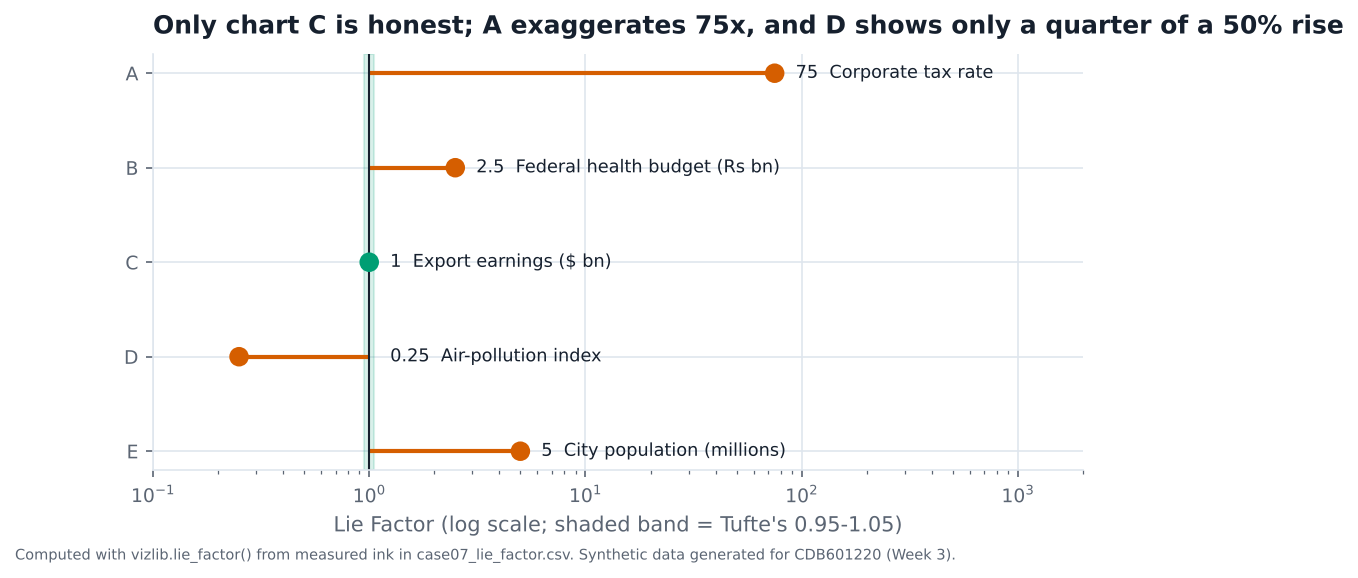

saved -> charts/partB_lie_factors.png


'/home/claude/week3/charts/partB_lie_factors.png'

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
lfs = audit["Lie Factor"]
cols = [GREEN if 0.95 <= v <= 1.05 else ORANGE for v in lfs]
ys = np.arange(len(lfs))[::-1]
ax.hlines(ys, 1, lfs.values, color=cols, lw=2)              # stem from honest (1.0), not a bar: a log axis has no zero
ax.scatter(lfs.values, ys, color=cols, s=70, zorder=3)
ax.set_yticks(ys); ax.set_yticklabels(audit.index)
ax.set_xscale("log")
ax.axvspan(0.95, 1.05, color=GREEN, alpha=0.15)
ax.axvline(1, color=INK, lw=1)
for y, (c, v) in zip(ys, lfs.items()):
    ax.text(max(v, 1) * 1.25, y, f"{v:g}  {audit.loc[c, 'subject']}", va="center", ha="left", fontsize=8.5)
ax.set_xlim(0.1, 2000)
ax.set_xlabel("Lie Factor (log scale; shaded band = Tufte's 0.95-1.05)")
ax.set_title("Only chart C is honest; A exaggerates 75x, and D shows only a quarter of a 50% rise")
finish(fig, "partB_lie_factors", "Computed with vizlib.lie_factor() from measured ink in case07_lie_factor.csv. " + SRC)

**What this chart shows.** Only chart C shows the change honestly (Lie Factor 1). Chart A blows a small rise up 75 times by cutting the baseline. B and E exaggerate because they scale area instead of length. D goes the other way and makes a 50% rise look like 12.5%.

## Q2 - which one is honest, and what the other four do wrong (3 marks)

**C (export earnings) is the only honest one.** Bars start at zero, so 5.0 cm to 6.0 cm is a +20% change in ink for a +20% change in data. LF = 1.00.

- **A (corporate tax rate), LF = 75.** The bars start at a 29.6% baseline, so the ink only encodes the bit *above* 29.6. Going from 30 to 32 is a 6.7% rise, but the visible tips grow from 4 mm to 24 mm, a 500% rise. A bar's length is supposed to be the value; here it is the value minus 29.6.
- **B (health budget), LF = 2.50.** The coin is scaled 1.5x in height *and* width, so its area (the ink the eye reads) grows 2.25x, a +125% change for a +50% budget.
- **D (pollution index), LF = 0.25.** The bars go from 8 cm to 9 cm (+12.5%) for a +50% rise in the index. Either the baseline is below zero or the bars were not drawn to scale; either way the ink shows only a quarter of the change.
- **E (city population), LF = 5.00.** The bubble's *radius* was made proportional to population, so its area grows as the square: 4x the radius is 16x the ink (+1,500%) for a 4x population (+300%).

## Q3 - which need `ink_dimension=2`, and what goes wrong at 1 (3 marks)

In [5]:
for c in audit.index[audit.ink_dimension == 2]:
    say(f"Chart {c}: LF with dimension 2 = {audit.loc[c, 'Lie Factor']}, with dimension left at 1 = {audit.loc[c, 'LF if dimension left at 1']}")

Chart B: LF with dimension 2 = 2.5, with dimension left at 1 = 1.0
Chart E: LF with dimension 2 = 5.0, with dimension left at 1 = 1.0


**B and E** encode the value by an area (a coin scaled in both directions, a bubble sized by radius), so they need `ink_dimension=2`. If you leave it at 1 you only compare one side of the shape, and **both come out at exactly 1.00 - "honest" - when they actually exaggerate 2.5x and 5x.** The eye reads the area, not the side, so measuring the side is measuring the wrong ink.

## Q4 - the one below 1 (2 marks)

**D, LF = 0.25.** An understated chart is still a distortion because the reader takes away the wrong size of change: a 50% jump in air pollution looks like a 12.5% bump. Tufte's rule is about the ink matching the data in both directions, not only about exaggeration. The people who benefit are whoever is responsible for the pollution, or the authority reporting it - a factory, a city government or a ministry that wants a worsening problem to look like it is under control. Understatement is just as useful for persuasion as exaggeration; it is only less often called out.

## Q5 - Chart F, the dual-axis chart (2 marks)

In [6]:
dual = pd.read_csv(DATA / "case07_dual_axis_series.csv")
# Each line, on its own axis, as fraction of axis height (left 50-80, right 40-56)
rev_h = (dual.revenue_pkr_m - 50) / 30
cost_h = (dual.cost_pkr_m - 40) / 16
lf_rev = vizlib.lie_factor(dual.revenue_pkr_m.iloc[0], dual.revenue_pkr_m.iloc[-1], rev_h.iloc[0], rev_h.iloc[-1])
lf_cost = vizlib.lie_factor(dual.cost_pkr_m.iloc[0], dual.cost_pkr_m.iloc[-1], cost_h.iloc[0], cost_h.iloc[-1])
say()
say("Chart F (dual axis) - each line measured against its OWN axis:")
say(f"  revenue: data {lf_rev[1]:+.1%}, line height {lf_rev[2]:+.1%}, LF {lf_rev[0]:.1f}")
say(f"  cost:    data {lf_cost[1]:+.1%}, line height {lf_cost[2]:+.1%}, LF {lf_cost[0]:.1f}")
gap_data = dual.revenue_pkr_m - dual.cost_pkr_m
gap_ink = rev_h - cost_h
say("  the claim is about the GAP between the lines:")
say("  gap in data (PKR m):          ", gap_data.tolist())
say("  gap on the canvas (axis frac):", gap_ink.round(3).tolist())
say("  The data gap is positive every month; the drawn gap starts NEGATIVE, so there is no ratio to take -> no Lie Factor for F.")
dual["profit"] = gap_data
say("  What the data shows: profit", dual.profit.tolist(), "PKR m, margin",
    f"{100*dual.profit.iloc[0]/dual.revenue_pkr_m.iloc[0]:.0f}% -> {100*dual.profit.iloc[-1]/dual.revenue_pkr_m.iloc[-1]:.0f}%")
(SUB / "partB_output.txt").write_text("\n".join(OUT), encoding="utf-8")
print("\nwrote submission/partB_output.txt")


Chart F (dual axis) - each line measured against its OWN axis:
  revenue: data +50.0%, line height +1300.0%, LF 26.0
  cost:    data +20.5%, line height +225.0%, LF 11.0
  the claim is about the GAP between the lines:
  gap in data (PKR m):           [8, 12, 14, 17, 20, 25]
  gap on the canvas (axis frac): [-0.183, -0.108, -0.071, -0.029, 0.012, 0.121]
  The data gap is positive every month; the drawn gap starts NEGATIVE, so there is no ratio to take -> no Lie Factor for F.
  What the data shows: profit [8, 12, 14, 17, 20, 25] PKR m, margin 15% -> 32%

wrote submission/partB_output.txt


**I cannot compute one honest Lie Factor for Chart F, and that is the point.** The formula assumes one quantity, one scale, and a baseline that means something, so that "how much more ink" can be compared with "how much more data". Chart F breaks all three: it has two quantities on two scales, and both baselines (50 and 40) were chosen freely. I can force a number out for each line separately (revenue LF about 26, cost LF about 11, because both axes are cut), but those numbers do not touch what the chart actually claims, which is *where one line sits relative to the other*. That relationship is set entirely by the two pairs of axis limits. Move the right axis to 30-56 and the "loss" disappears without changing a single number in the data. In fact the gap in the data is positive every month while the drawn gap starts negative, so the "graphic effect" does not even have the same sign as the data effect.

**What the data actually shows:** both columns are PKR millions, so they belong on one axis. Revenue is above cost in all six months. Profit rises from 8 to 25 PKR m, and the margin from 15% to 32%. ShaheenGo never ran at a loss. This is why the course rule says *never a dual-axis chart* - the problem is not a distortion that can be measured, it is a comparison that the chart makes up.